# NLP Assignment 4: Fine-Tuning BERT (IMDB Dataset)

## Objective
Build a text classification model using BERT and evaluate performance using multiple metrics.

In [1]:
import pandas as pd
import numpy as np
import torch

from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import Trainer, TrainingArguments

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import torch
torch.cuda.is_available()

True

# Load IMDB dataset using Hugging Face

In [3]:
dataset = load_dataset("imdb")

train_df = pd.DataFrame(dataset["train"])
test_df = pd.DataFrame(dataset["test"])

df = pd.concat([train_df, test_df]).reset_index(drop=True)
df.head()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


,text,label
0,I rented I AM CURIOUS-YELLOW from my video sto...,0
1,"""I Am Curious: Yellow"" is a risible and preten...",0
2,If only to avoid making this type of film in t...,0
3,This film was probably inspired by Godard's Ma...,0
4,"Oh, brother...after hearing about this ridicul...",0


# Data cleaning and sampling

In [11]:
df.dropna(inplace=True)

df['text'] = df['text'].str.lower()

# Reduce size for faster training
df = df.sample(3000, random_state=42)

# Train / Validation / Test split

In [12]:
train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    df['text'], df['label'], test_size=0.3, random_state=42)

val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts, temp_labels, test_size=0.5, random_state=42)

# Convert text into BERT tokens

In [13]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

train_encodings = tokenizer(list(train_texts), truncation=True, padding=True)
val_encodings = tokenizer(list(val_texts), truncation=True, padding=True)
test_encodings = tokenizer(list(test_texts), truncation=True, padding=True)

# Create PyTorch dataset

In [14]:
class Dataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels.reset_index(drop=True)

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = Dataset(train_encodings, train_labels)
val_dataset = Dataset(val_encodings, val_labels)
test_dataset = Dataset(test_encodings, test_labels)

# Load BERT model

In [15]:
model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased", num_labels=2
)

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


# Training configuration

In [16]:
training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    logging_dir="./logs",
    do_eval=True
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


# Train base model

In [17]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {"accuracy": (preds == labels).mean()}

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

trainer.train()

Step,Training Loss


Step,Training Loss
500,0.318336


TrainOutput(global_step=789, training_loss=0.24132024138901473, metrics={'train_runtime': 663.4587, 'train_samples_per_second': 9.496, 'train_steps_per_second': 1.189, 'total_flos': 1657599648768000.0, 'train_loss': 0.24132024138901473, 'epoch': 3.0})

# Freeze all BERT layers

In [18]:
model_frozen = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased", num_labels=2
)

for param in model_frozen.bert.parameters():
    param.requires_grad = False

trainer_frozen = Trainer(
    model=model_frozen,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset
)

trainer_frozen.train()

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
500,0.708765


TrainOutput(global_step=789, training_loss=0.7043237529024576, metrics={'train_runtime': 240.3968, 'train_samples_per_second': 26.207, 'train_steps_per_second': 3.282, 'total_flos': 1657599648768000.0, 'train_loss': 0.7043237529024576, 'epoch': 3.0})

# Fine-tune last two layers

In [19]:
model_last = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased", num_labels=2
)

for name, param in model_last.bert.named_parameters():
    if "encoder.layer.10" in name or "encoder.layer.11" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

trainer_last = Trainer(
    model=model_last,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset
)

trainer_last.train()

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
500,0.393408


TrainOutput(global_step=789, training_loss=0.3436374059950293, metrics={'train_runtime': 292.9081, 'train_samples_per_second': 21.508, 'train_steps_per_second': 2.694, 'total_flos': 1657599648768000.0, 'train_loss': 0.3436374059950293, 'epoch': 3.0})

# Function to evaluate models

In [20]:
def evaluate_model(trainer, dataset, true_labels):
    preds = trainer.predict(dataset)
    y_pred = np.argmax(preds.predictions, axis=1)

    report = classification_report(true_labels, y_pred, output_dict=True)
    cm = confusion_matrix(true_labels, y_pred)

    return report, cm

# Evaluate all models

In [21]:
base_report, base_cm = evaluate_model(trainer, test_dataset, test_labels)
frozen_report, frozen_cm = evaluate_model(trainer_frozen, test_dataset, test_labels)
last_report, last_cm = evaluate_model(trainer_last, test_dataset, test_labels)

# Print metrics

In [22]:
def print_metrics(name, report):
    print(f"\n{name}")
    print("Accuracy:", report['accuracy'])
    print("Precision:", report['weighted avg']['precision'])
    print("Recall:", report['weighted avg']['recall'])
    print("F1:", report['weighted avg']['f1-score'])

print_metrics("Base", base_report)
print_metrics("Frozen", frozen_report)
print_metrics("Last 2 Layers", last_report)


Base
Accuracy: 0.9333333333333333
Precision: 0.9333333333333333
Recall: 0.9333333333333333
F1: 0.9333333333333333

Frozen
Accuracy: 0.5088888888888888
Precision: 0.51042096202463
Recall: 0.5088888888888888
F1: 0.5053874880967167

Last 2 Layers
Accuracy: 0.9088888888888889
Precision: 0.9089777777777778
Recall: 0.9088888888888889
F1: 0.9088929384515854


# Plot confusion matrices

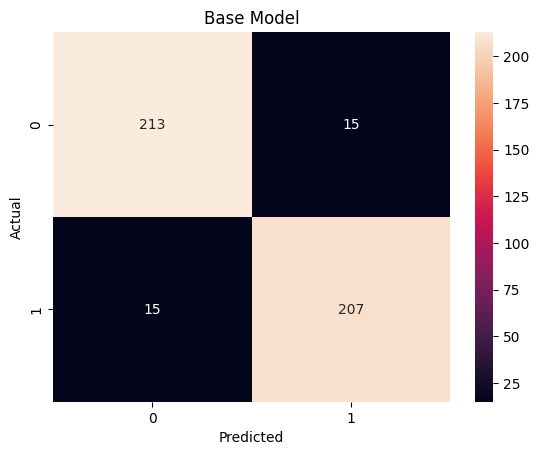

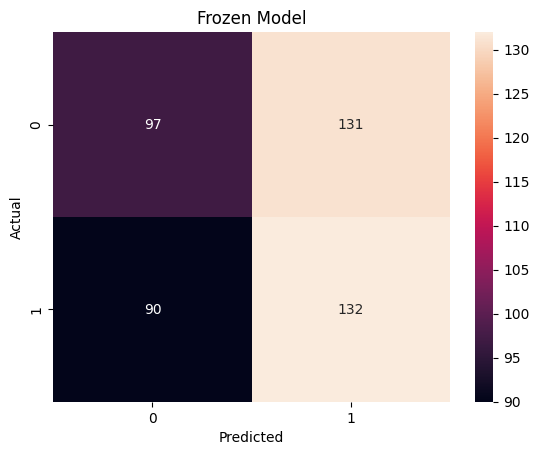

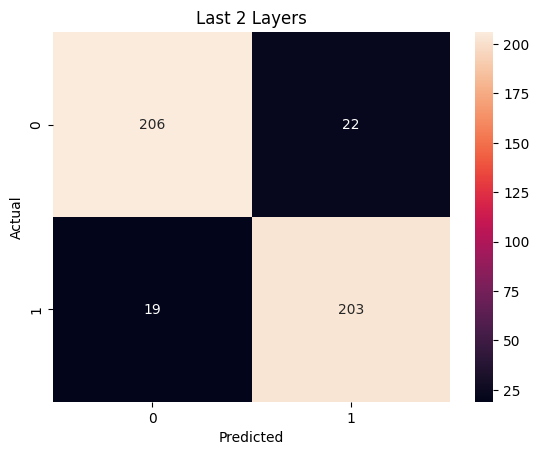

In [23]:
def plot_cm(cm, title):
    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

plot_cm(base_cm, "Base Model")
plot_cm(frozen_cm, "Frozen Model")
plot_cm(last_cm, "Last 2 Layers")

# Compare results

In [24]:
comparison = pd.DataFrame({
    "Model": ["Base", "Frozen", "Last 2 Layers"],
    "Accuracy": [
        base_report['accuracy'],
        frozen_report['accuracy'],
        last_report['accuracy']
    ],
    "F1 Score": [
        base_report['weighted avg']['f1-score'],
        frozen_report['weighted avg']['f1-score'],
        last_report['weighted avg']['f1-score']
    ]
})

comparison

,Model,Accuracy,F1 Score
0,Base,0.933333,0.933333
1,Frozen,0.508889,0.505387
2,Last 2 Layers,0.908889,0.908893


# Analysis

The performance comparison across different fine-tuning strategies shows clear differences in how much model adaptation impacts results.

## Performance Overview
- **Base Model (Full Fine-Tuning)** achieved the highest performance with an accuracy and F1 score of **0.93**.
- **Frozen BERT Model** performed poorly with accuracy around **0.51**, which is close to random guessing.
- **Last 2 Layers Fine-Tuned Model** achieved strong performance with an accuracy of **0.91**, slightly lower than the fully fine-tuned model.

## Key Insights

### 1. Full Fine-Tuning Performs Best
The base model updates all BERT parameters, allowing it to fully adapt to the dataset. This results in the highest accuracy and F1 score, indicating better understanding of contextual patterns in text.

### 2. Frozen BERT Fails to Learn Task-Specific Features
When all BERT layers are frozen, only the classifier layer is trained. This severely limits learning capacity, leading to poor performance close to random classification. This shows that pre-trained features alone are insufficient for this task.

### 3. Fine-Tuning Last Layers is a Strong Trade-off
Fine-tuning only the last two layers achieves performance close to the fully fine-tuned model, with significantly reduced training complexity. This indicates that higher layers in BERT capture more task-specific features.

## Trade-Off Analysis

| Approach | Performance | Training Time | Efficiency |
|--------|------------|--------------|-----------|
| Full Fine-Tuning | Highest | High | Moderate |
| Frozen BERT | Very Low | Very Low | Poor |
| Last 2 Layers | High | Medium | Best Balance |

##  Final Conclusion
- The **fully fine-tuned BERT model** provides the best overall performance.
- The **last 2 layers fine-tuning approach** offers an excellent balance between accuracy and computational efficiency.
- Freezing BERT layers is not suitable for this task as it significantly reduces model performance.

Overall, the experiment demonstrates that **fine-tuning depth directly impacts model effectiveness**, with deeper fine-tuning yielding better results.